# VAE Celeba Images

In [1]:
%reload_ext watermark
%watermark -a 'Yasir Awais Butt' -v -p torch

Author: Yasir Awais Butt

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.13.0

torch: 2.11.0+cu128



## Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import celeba
from torchvision import datasets
from util_data import plot_modified_faces, compute_average_faces

In [3]:
RANDOM_SEED = 42
NUM_EPOCHS = 5
BATCH_SIZE = 256
LEARNING_RATE = 0.0005

In [4]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {DEVICE}")
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


Using device: cuda


## Dataset

In [5]:
transform = transforms.Compose([
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor()]
)

In [6]:
train_dataset = datasets.CelebA(root = "data", 
                              split = "train", 
                              download = True,
                              transform = transform)
test_dataset = datasets.CelebA(root = "data", 
                              split = "test", 
                              download = True,
                              transform = transform)


In [7]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2)

In [8]:
torch.manual_seed(RANDOM_SEED)
print('Training Dataset')
for images, labels in train_loader:
    print(f"Image batch dimensions: {images.shape}")
    print(f"Label batch dimensions: {labels.shape}")
    break

Training Dataset
Image batch dimensions: torch.Size([256, 3, 128, 128])
Label batch dimensions: torch.Size([256, 40])


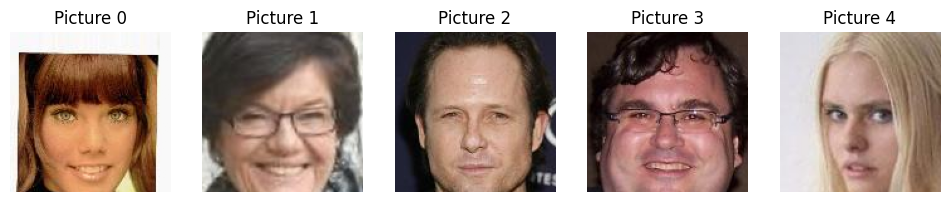

In [9]:
plt.figure(figsize=(12, 3))
for i in range(5):
    images, labels = next(iter(train_loader))
    img = images[0]  # first image in the batch
    plt.subplot(1, 5, i + 1)
    
    plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(f"Picture {i}")
plt.show()    

# 1) Image Manipulation of Original Space

### Compute Average Faces

In [10]:
avg_img_with_feat, avg_img_without_feat = compute_average_faces(
    feature_idx = 31,
    image_dim = (3, 128, 128),
    data_loader = train_loader, 
    device = None,
    encoding_fn = None
)

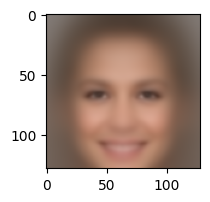

In [11]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow((avg_img_with_feat).permute(1, 2, 0))
plt.show()

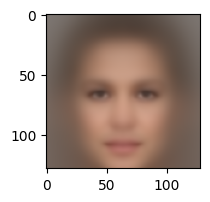

In [12]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow((avg_img_without_feat).permute(1, 2, 0))
plt.show()

### Manipulate Example Face Image

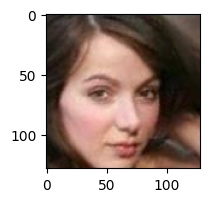

In [13]:
EXAMPLE_IMAGE = images[1]
fig, ax = plt.subplots(figsize=(2, 2))

ax.imshow(EXAMPLE_IMAGE.permute(1, 2, 0))
plt.show()

In [14]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.036689132..1.0278184].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.040570423..0.9920442].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.073378265..1.0737674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10074869..0.9880099].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1100674..1.120455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16092695..1.0053126].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0

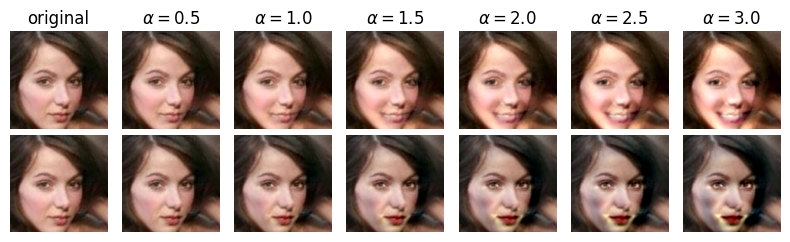

In [15]:
diff = (avg_img_with_feat - avg_img_without_feat)
plot_modified_faces(original=images[1],
                    diff=diff)

plt.tight_layout()
plt.show()

In [16]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)
class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()
        

    def forward(self, x):
        return x[:, :, :128, :128]
    
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias = False),  # (32, 64, 64)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias = False), # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias = False), # (128, 16, 16)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias = False), # (256, 8, 8)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.Flatten(), # (64*8*8,)
        )
        self.z_mean = nn.Linear(4096, 200)
        self.z_log_var = nn.Linear(4096, 200)

        self.decoder = nn.Sequential(
            nn.Linear(200, 4096),
            Reshape(-1, 64, 8, 8), # (256, 8, 8)
            #
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, bias = False), # (128, 14, 14)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, bias = False), # (64, 28, 28)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, bias = False), # (32, 56, 56)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.25),
            #
            nn.ConvTranspose2d(32, 3, kernel_size=3,stride=2,padding=1, bias = False), # (3 ,112 ,112)
            Trim(),
            nn.Sigmoid() 
        )
    def encoding_fn(self, x):
        h = self.encoder(x)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)
        return self.reparameterize(z_mean, z_log_var)
    def reparameterize(self, z_mu, z_log_var):
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(z_mu.get_device())
        z = z_mu + eps * torch.exp(z_log_var/2.) 
        return z
    
    def forward(self,x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded, z_mean, z_log_var, decoded

In [17]:
model = VAE()
model.load_state_dict(torch.load('vae_celeba_02.pt', map_location=torch.device('cpu')))
model.to(DEVICE);

In [18]:
avg_img_with_feat, avg_img_without_feat = compute_average_faces(
    feature_idx=31, # smiling
    image_dim=200,
    data_loader=train_loader,
    device=DEVICE,
    encoding_fn=model.encoding_fn)

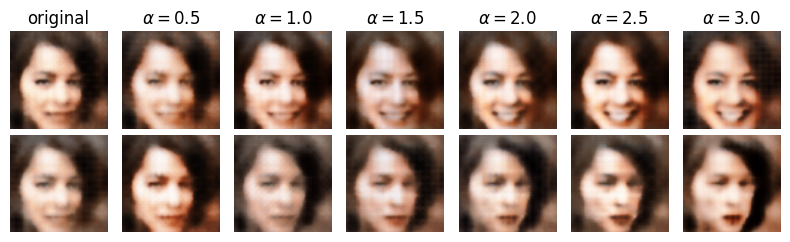

In [19]:
diff = (avg_img_with_feat - avg_img_without_feat)

example_img = EXAMPLE_IMAGE.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    encoded = model.encoding_fn(example_img).squeeze(0).to('cpu')

plot_modified_faces(original=encoded,
                    decoding_fn=model.decoder,
                    device=DEVICE,
                    diff=diff)

plt.tight_layout()
plt.show()

### Compute Average Faces in Latent Space -- With or Without Glasses

In [20]:
avg_img_with_feat, avg_img_without_feat = compute_average_faces(
    feature_idx=15, # eyeglasses
    image_dim=200,
    data_loader=train_loader,
    device=DEVICE,
    encoding_fn=model.encoding_fn)

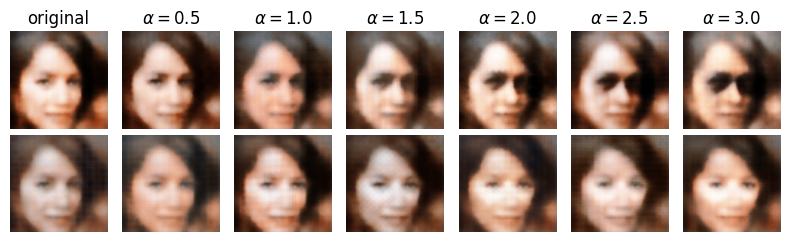

In [21]:
diff = (avg_img_with_feat - avg_img_without_feat)

example_img = EXAMPLE_IMAGE.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    encoded = model.encoding_fn(example_img).squeeze(0).to('cpu')

plot_modified_faces(original=encoded,
                    decoding_fn=model.decoder,
                    device=DEVICE,
                    diff=diff)

plt.tight_layout()
plt.show()